# Fine-Tuning LLMs with LoRA and QLoRA — runnable notebook

**Sreeja Muvva — ARTI 4555/6555 (MS in Artificial Intelligence)**

Companion code for `Fine_Tuning_LLMs_Tutorial.md`. Section numbers below refer to that document.

Runs end to end on a **free Google Colab T4 GPU (16 GB)**:
*Runtime → Change runtime type → T4 GPU*.

Expect roughly 15–35 minutes total, most of it in the training cell.

> Every code cell here is extracted verbatim from the written tutorial, so the two
> artifacts stay in sync.

## 1. Install (§7.3)

One `pip` command on purpose — the resolver has to see every constraint at once.
The upper bounds come from **Unsloth's own metadata**, not guesswork: as of July 2026
Unsloth requires `trl<=0.24.0` and `transformers<=5.5.0`, even though newer releases of
both exist on PyPI. Installing "the latest" is how this notebook breaks.

In [1]:
# Cell 1 — install (Colab). Takes ~2-5 minutes.
#
# ONE pip command, on purpose: the resolver has to see every constraint at once.
# Installing unsloth first and then trl/transformers separately lets the second
# command silently upgrade them out of the window unsloth actually supports.
#
# The upper bounds below come from unsloth's own metadata (see 7.2), not guesswork.
# The trl>=0.20 lower bound guarantees the modern API this notebook is written
# against (max_length, processing_class).
!pip install -q unsloth "trl>=0.20,<=0.24" "transformers<=5.5.0" "peft>=0.18" accelerate bitsandbytes datasets

# If the install misbehaves on Colab, the dev build is sometimes ahead of PyPI:
# !pip install -q --upgrade --no-cache-dir "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225

Optional: ask the installed package what it actually supports, rather than trusting
this notebook's pins forever (§7.2).

In [2]:
# What does Unsloth actually support? Ask the installed package, don't guess.
from importlib.metadata import requires

for r in requires("unsloth") or []:
    if r.split()[0].split("[")[0] in {"trl", "transformers", "peft", "torch"}:
        print(r)

## 2. Environment check (§7.4)

Two seconds, saves an hour. Confirms the GPU, picks fp16 vs bf16 once (**a T4 has no
bfloat16**), and asserts the resolved `trl` version is inside the window this notebook
targets — so a bad resolution fails here instead of twenty minutes into training.

In [13]:
# Cell 2 — verify GPU and record the exact environment
import torch, platform

assert torch.cuda.is_available(), "No GPU! Runtime -> Change runtime type -> T4 GPU"

gpu   = torch.cuda.get_device_name(0)
vram  = torch.cuda.get_device_properties(0).total_memory / 1e9
BF16 = torch.cuda.get_device_capability()[0] >= 8
print(f"GPU             : {gpu} ({vram:.1f} GB)")
print(f"bfloat16 support: {BF16}   -> we will train in {'bf16' if BF16 else 'fp16'}")
print(f"Python          : {platform.python_version()} | torch {torch.__version__}")

import trl, transformers, peft
print(f"trl {trl.__version__} | transformers {transformers.__version__} | peft {peft.__version__}")

# Fail loudly NOW if the resolver drifted out of the window this notebook targets.
from packaging.version import parse as V
assert V("0.20") <= V(trl.__version__) <= V("0.24.0"), (
    f"trl {trl.__version__} is outside the 0.20-0.24 window this notebook targets. "
    "Below 0.20 the SFTConfig argument names differ; above 0.24 unsloth does not "
    "declare support. Re-run Cell 1, and see section 7.2."
)

GPU             : Tesla T4 (15.6 GB)
bfloat16 support: False   -> we will train in fp16
Python          : 3.12.13 | torch 2.11.0+cu128
trl 0.24.0 | transformers 5.5.0 | peft 0.19.1


## 3. Load the base model in 4-bit + attach LoRA adapters (§8.1)

This is QLoRA: a frozen 4-bit base with small trainable adapters on top.

Compare the printed trainable-parameter count against the hand calculation in §6.3
(≈ 18.5 M, about 1.2% of the model). A mismatch means you targeted different modules
than you thought.

In [14]:
# Cell 3 — this is the "QLoRA" setup: 4-bit frozen base + trainable LoRA adapters
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LEN = 2048
SEED        = 3407

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/Qwen2.5-1.5B-Instruct",
    # Faster download (already quantized): "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"
    # Scale up later with:                 "unsloth/Qwen2.5-7B-Instruct"
    max_seq_length = MAX_SEQ_LEN,
    load_in_4bit   = True,   # <- the "Q" in QLoRA
    dtype          = None,   # None = auto: fp16 on T4/V100, bf16 on Ampere+
)

model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,            # LoRA rank -> capacity (see 6.3 for the param count)
    lora_alpha     = 32,            # update scale; ~2x rank is a solid default
    lora_dropout   = 0.05,          # light regularization; 0 is also common
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",   # attention
                      "gate_proj", "up_proj", "down_proj"],     # MLP
    bias           = "none",
    use_gradient_checkpointing = "unsloth",   # big activation-memory saver
    use_rslora     = False,         # set True if you raise r to 64+
    random_state   = SEED,
)

model.print_trainable_parameters()   # compare this against your hand calculation from 6.3

==((====))==  Unsloth 2026.7.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 4. Load, format, and split the dataset (§8.2)

Two things matter here:

1. **Use the tokenizer's own chat template.** A template mismatch degrades quality
   silently, with no error message.
2. **Split before formatting.** That keeps the original `instruction` / `input` /
   `output` columns on the held-out half, so the ROUGE cell later can score against data
   the model never trained on.

Eyeball the printed example — you should see `<|im_start|>user` / `<|im_end|>` control
tokens wrapping the content.

In [5]:
# Cell 4 — load a public instruction dataset, apply the chat template, hold out a validation split
from datasets import load_dataset

raw = load_dataset("yahma/alpaca-cleaned", split="train[:2000]")   # 2k is plenty for a demo

def build_prompt(ex):
    """Alpaca rows have an optional 'input' field that supplements the instruction."""
    return ex["instruction"] if not ex["input"] else f'{ex["instruction"]}\n\n{ex["input"]}'

def format_example(ex):
    messages = [
        {"role": "user",      "content": build_prompt(ex)},
        {"role": "assistant", "content": ex["output"]},
    ]
    # add_generation_prompt=False -> we want the completed assistant turn, for training
    ex["text"] = tokenizer.apply_chat_template(messages, tokenize=False,
                                               add_generation_prompt=False)
    return ex

# Split BEFORE formatting. This keeps the original instruction/input/output columns on the
# held-out half, so section 11.3 can score ROUGE against data the model never trained on.
# (Formatting first and splitting after would leave us with only the 'text' column.)
split                = raw.train_test_split(test_size=0.15, seed=SEED)
raw_train, raw_eval  = split["train"], split["test"]

train_ds = raw_train.map(format_example, remove_columns=raw_train.column_names)
eval_ds  = raw_eval.map(format_example,  remove_columns=raw_eval.column_names)

print(f"train {len(train_ds)} | eval {len(eval_ds)}")
print("-" * 60)
print(train_ds[0]["text"][:600])   # ALWAYS eyeball one formatted example

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

alpaca_data_cleaned.json: reconstructing file:   0%|          |  0.00B / 44.3MB            

alpaca_data_cleaned.json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/51760 [00:00<?, ? examples/s]

Map:   0%|          | 0/1700 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

train 1700 | eval 300
------------------------------------------------------------
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Redact a confidential document.

John Smith is a suspect in the recent murder.<|im_end|>
<|im_start|>assistant
[REDACTED] is a suspect in the recent [REDACTED].<|im_end|>



## 5. Compatibility shim (§8.3)

TRL has renamed these arguments more than once. Rather than assume a version, detect the
installed API: `processing_class` vs `tokenizer`, `max_length` vs `max_seq_length`.

In [6]:
# Cell 5 — detect the installed TRL API instead of assuming it
import inspect, trl
from dataclasses import fields
from trl import SFTConfig, SFTTrainer
from packaging.version import parse as V

_CFG_FIELDS      = {f.name for f in fields(SFTConfig)}
_TRAINER_PARAMS  = set(inspect.signature(SFTTrainer.__init__).parameters)
_NEW_TO_OLD      = {"max_length": "max_seq_length"}   # renamed in TRL 0.20

def make_sft_config(**kw):
    """Build an SFTConfig using modern names, downgrading them if TRL is older."""
    out = {}
    for k, v in kw.items():
        if k in _CFG_FIELDS:
            out[k] = v
        elif k in _NEW_TO_OLD and _NEW_TO_OLD[k] in _CFG_FIELDS:
            out[_NEW_TO_OLD[k]] = v
        else:
            print(f"[compat] SFTConfig does not accept '{k}' in trl {trl.__version__} — dropping it")
    return SFTConfig(**out)

if "processing_class" in _TRAINER_PARAMS:
    TOKENIZER_KW = "processing_class"
elif "tokenizer" in _TRAINER_PARAMS:
    TOKENIZER_KW = "tokenizer"
else:                                     # signature hidden behind **kwargs
    TOKENIZER_KW = "processing_class" if V(trl.__version__) >= V("0.16") else "tokenizer"

print(f"[compat] trl {trl.__version__}: passing the tokenizer as '{TOKENIZER_KW}'")

[compat] trl 0.24.0: passing the tokenizer as 'processing_class'


## 6. Train (§8.4)

Training loss prints every 10 steps, validation loss every 50.

`load_best_model_at_end=True` restores the lowest-*validation*-loss checkpoint rather
than the last step's weights — on a small dataset that single argument is worth more than
most hyperparameter tuning.

**This is the slow cell: roughly 10–25 minutes on a free T4.**

In [15]:
BF16 = torch.cuda.get_device_capability()[0] >= 8
print(f"BF16 = {BF16}  |  {torch.cuda.get_device_name(0)}  cc={torch.cuda.get_device_capability()}")

BF16 = False  |  Tesla T4  cc=(7, 5)


In [16]:
# Cell 6 — supervised fine-tuning with TRL's SFTTrainer
cfg = make_sft_config(
    output_dir                  = "outputs",
    dataset_text_field          = "text",
    max_length                  = MAX_SEQ_LEN,   # 'max_seq_length' on TRL < 0.20 (shim handles it)

    per_device_train_batch_size = 2,     # rows per GPU step
    gradient_accumulation_steps = 4,     # -> effective batch = 2 x 4 = 8
    num_train_epochs            = 1,     # 1 epoch is enough for a demo
    learning_rate               = 2e-4,  # typical for LoRA/QLoRA
    lr_scheduler_type           = "cosine",
    warmup_ratio                = 0.03,
    weight_decay                = 0.01,
    max_grad_norm               = 1.0,
    optim                       = "paged_adamw_8bit",

    fp16 = not BF16,     # T4 -> fp16
    bf16 = BF16,         # Ampere+ -> bf16

    logging_steps               = 10,
    eval_strategy               = "steps",
    eval_steps                  = 50,
    save_strategy               = "steps",
    save_steps                  = 50,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,
    save_total_limit            = 2,

    packing                     = False,  # keep False for instruction SFT
    seed                        = SEED,
    report_to                   = "none", # set "wandb"/"tensorboard" to log properly
)

trainer = SFTTrainer(
    model         = model,
    train_dataset = train_ds,
    eval_dataset  = eval_ds,
    args          = cfg,
    **{TOKENIZER_KW: tokenizer},
)

trainer_stats = trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1700 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/300 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,700 | Num Epochs = 1 | Total steps = 213
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
50,1.044461,1.037637
100,1.010822,1.028036
150,1.013631,1.022120
200,1.052172,1.021170
213,1.065720,1.021129


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-50/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-150/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-213/tokenizer_config.json.


## 7. Training report (§8.5)

Compare the peak VRAM figure against your prediction from §6.2.

In [18]:
import math
peak_gb = torch.cuda.max_memory_reserved() / 1e9
runtime = trainer_stats.metrics["train_runtime"]
evals   = [h["eval_loss"] for h in trainer.state.log_history if "eval_loss" in h]
best    = trainer.state.best_metric if trainer.state.best_metric is not None else min(evals)

print(f"Runtime        : {runtime/60:.1f} min")
print(f"Peak VRAM      : {peak_gb:.2f} GB of {vram:.1f} GB")
print(f"Evals recorded : {len(evals)} (last {evals[-1]:.4f})")
print(f"Best eval loss : {best:.4f}")
print(f"Perplexity     : {math.exp(best):.2f}")

Runtime        : 9.4 min
Peak VRAM      : 4.06 GB of 15.6 GB
Evals recorded : 6 (last 1.0211)
Best eval loss : 1.0211
Perplexity     : 2.78


In [19]:
# Cell 7 — record what actually happened (useful evidence for your write-up)
import math

peak_gb = torch.cuda.max_memory_reserved() / 1e9
runtime = trainer_stats.metrics["train_runtime"]
final   = trainer.evaluate()

print(f"Runtime        : {runtime/60:.1f} min")
print(f"Peak VRAM      : {peak_gb:.2f} GB of {vram:.1f} GB")
print(f"Final eval loss: {final['eval_loss']:.4f}")
print(f"Perplexity     : {math.exp(final['eval_loss']):.2f}")

RuntimeError: on_train_begin must be called before on_evaluate

In [20]:
import math

peak_gb = torch.cuda.max_memory_reserved() / 1e9
runtime = trainer_stats.metrics["train_runtime"]
evals   = [h["eval_loss"] for h in trainer.state.log_history if "eval_loss" in h]

print(f"Runtime        : {runtime/60:.1f} min")
print(f"Peak VRAM      : {peak_gb:.2f} GB of {vram:.1f} GB")

if evals:
    best = trainer.state.best_metric if trainer.state.best_metric is not None else min(evals)
    print(f"Evals recorded : {len(evals)} (last {evals[-1]:.4f})")
    print(f"Best eval loss : {best:.4f}")
    print(f"Perplexity     : {math.exp(best):.2f}")
else:
    print("No eval_loss in log_history — check eval_strategy/eval_steps in Cell 6")

Runtime        : 9.4 min
Peak VRAM      : 4.06 GB of 15.6 GB
Evals recorded : 7 (last 1.0211)
Best eval loss : 1.0211
Perplexity     : 2.78


## 7b. Plot the loss curves (§8.6)

Saves `loss_curves.png` — the figure the reproducibility checklist in §19 asks for.

If the validation line turns upward while training loss keeps falling, that is the
overfitting picture from §10.1.

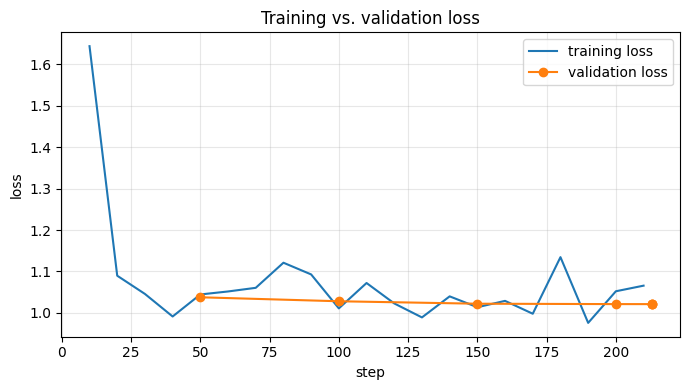

Best validation loss 1.0211 at step 213 (this is the checkpoint load_best_model_at_end restored)


In [21]:
# Cell 7b — training vs. validation loss, straight from the trainer's log history
import matplotlib.pyplot as plt

hist  = trainer.state.log_history
train = [(h["step"], h["loss"])      for h in hist if "loss"      in h]
val   = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

fig, ax = plt.subplots(figsize=(7, 4))
if train:
    ax.plot(*zip(*train), label="training loss", linewidth=1.5)
if val:
    ax.plot(*zip(*val), label="validation loss", marker="o", linewidth=1.5)

ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title("Training vs. validation loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()

if val:
    best_step, best_loss = min(val, key=lambda p: p[1])
    print(f"Best validation loss {best_loss:.4f} at step {best_step} "
          f"(this is the checkpoint load_best_model_at_end restored)")

## Optional — train on responses only (§8.7)

The run above computes loss over the **whole** sequence, including the user's prompt,
which spends capacity teaching the model to generate questions. Masking the prompt so
loss lands only on the assistant's reply is the better practice.

**Left commented out on purpose.** Enabling it requires re-running the training cell, and
the resulting loss is **not comparable** to the number above — you would be averaging over
a smaller, harder set of tokens (§10.3). Uncomment, then re-run cell 6.

In [22]:
# # Option A — Unsloth helper (works with Qwen2.5 / ChatML templates)
# from unsloth.chat_templates import train_on_responses_only
#
# trainer = train_on_responses_only(
#     trainer,
#     instruction_part = "<|im_start|>user\n",
#     response_part    = "<|im_start|>assistant\n",
# )
#
# # Option B — TRL native (requires a conversational 'messages' column instead of 'text',
# # and a chat template containing {% generation %} markers; TRL patches some model
# # families automatically). Set assistant_only_loss=True in SFTConfig.

## 8. Generation helper (§11.1)

Greedy decoding by default: sampling adds variance that would swamp the before/after
effect we are trying to measure.

In [23]:
# Cell 8 — inference helper
from unsloth import FastLanguageModel
import torch

FastLanguageModel.for_inference(model)   # ~2x faster generation

@torch.no_grad()
def generate(prompt, max_new_tokens=192, greedy=True):
    msgs   = [{"role": "user", "content": prompt}]
    # return_dict=True gives us input_ids AND a correct attention_mask. Building the
    # mask by hand with torch.ones_like() is wrong the moment anything is padded.
    inputs = tokenizer.apply_chat_template(
        msgs, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device)

    # Only pass sampling knobs when actually sampling; handing temperature/top_p to a
    # greedy call just produces warnings.
    sampling = dict(do_sample=False) if greedy else dict(
        do_sample=True, temperature=0.7, top_p=0.9,
    )

    out = model.generate(
        **inputs,
        max_new_tokens = max_new_tokens,
        pad_token_id   = tokenizer.pad_token_id or tokenizer.eos_token_id,
        **sampling,
    )
    prompt_len = inputs["input_ids"].shape[1]
    return tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True)

print(generate("Explain LoRA to a beginner in two sentences."))

Both `max_new_tokens` (=192) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


LoRA is an advanced machine learning technique that allows for faster training of deep neural networks by using smaller models as building blocks. It helps improve the efficiency and accuracy of AI systems while reducing their computational requirements.


## 9. Base vs. fine-tuned (§11.2)

LoRA leaves the base weights untouched, so toggling the adapter off recovers the original
model from the same memory — no second load required. This is the comparison that
actually demonstrates what fine-tuning did.

Score the output by hand against the rubric table in §11.2. Note that prompt 4 tests a
**fact**, not a behavior — if it is unchanged, that is the expected result, and it
reinforces §3: fine-tuning is not a knowledge-injection tool.

In [24]:
# Cell 9 — same weights, adapter on vs. off
PROMPTS = [
    "Give three tips for writing clear code.",
    "Summarize the water cycle in two sentences.",
    "Convert this to a bulleted list: we need milk, eggs, and bread.",
    "What is the capital of Australia?",
    "Write a polite email declining a meeting invitation.",
]

for p in PROMPTS:
    with model.disable_adapter():          # <- base model behavior
        before = generate(p)
    after = generate(p)                    # <- fine-tuned behavior
    print("=" * 78)
    print("PROMPT :", p)
    print("\n[BASE]\n", before)
    print("\n[TUNED]\n", after)

Both `max_new_tokens` (=192) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT : Give three tips for writing clear code.

[BASE]
 1. Use descriptive variable and function names: This helps other developers understand what the code is doing at a glance.
2. Follow consistent coding conventions: Consistent formatting, naming conventions, and style guidelines make it easier to read and maintain code over time.
3. Write modular code: Breaking down complex problems into smaller, manageable pieces can help prevent errors and improve readability. Each module should have its own purpose and be responsible for a specific task.

[TUNED]
 1. Use descriptive variable names: It's important to use meaningful and descriptive names for variables so that it is easy for other developers or future you to understand the purpose of each variable.

2. Follow coding standards: Consistent formatting, indentation, naming conventions, and commenting can make your code easier to read and maintain. Following established coding standards helps ensure consistency across different parts 

Both `max_new_tokens` (=192) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT : Summarize the water cycle in two sentences.

[BASE]
 The water cycle involves evaporation from the Earth's surface, condensation into clouds, precipitation as rain or snow, and collection in bodies of water like oceans, lakes, rivers, and groundwater.

[TUNED]
 The water cycle is a continuous process that involves evaporation from oceans and other bodies of water, condensation into clouds, precipitation as rain or snow, and collection back into oceans and other bodies of water.


Both `max_new_tokens` (=192) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT : Convert this to a bulleted list: we need milk, eggs, and bread.

[BASE]
 - Milk
- Eggs
- Bread

[TUNED]
 - We need milk.
- We need eggs.
- We need bread.


Both `max_new_tokens` (=192) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT : What is the capital of Australia?

[BASE]
 The capital of Australia is Canberra.

[TUNED]
 The capital city of Australia is Canberra.


Both `max_new_tokens` (=192) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT : Write a polite email declining a meeting invitation.

[BASE]
 Subject: Re: Invitation to [Meeting Name]

Dear [Name],

Thank you for the invitation to join our upcoming meeting on [Date]. I appreciate your offer and would like to decline this time.

Unfortunately, I am currently unavailable at that date due to an important personal commitment. However, please know that I value your invitation and hope we can find another suitable time in the future when both of us have availability.

I apologize for any inconvenience this may cause and thank you once again for considering my request.

Best regards,

[Your Full Name]  
[Your Contact Information]

[TUNED]
 Dear [Name],

I hope this message finds you well.

I am writing to decline your request for a meeting on the date and time that was previously scheduled. I apologize if my previous response has caused any inconvenience or misunderstanding, but unfortunately, it is not possible for me to attend the meeting at the specified time

## 10. An automatic metric (§11.3)

ROUGE against **held-out** references. Because cell 4 split before formatting, `raw_eval`
still carries the original columns and the model has never seen any of these rows.

Treat ROUGE as a *relative* signal between your own runs — for open-ended instruction
following there are many good answers, and surface overlap with a single reference does
not capture that.

In [25]:
# Cell 10 — ROUGE against HELD-OUT references (data the model never trained on)
!pip install -q evaluate rouge_score
import evaluate

n       = 25
sample  = raw_eval.select(range(min(n, len(raw_eval))))
refs    = sample["output"]
prompts = [build_prompt(ex) for ex in sample]     # same prompt construction as training
preds   = [generate(p, max_new_tokens=256) for p in prompts]

rouge = evaluate.load("rouge")
print(rouge.compute(predictions=preds, references=refs))

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.4 MB/s eta 0:00:00


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

{'rouge1': np.float64(0.52481309141097), 'rouge2': np.float64(0.3062700304027447), 'rougeL': np.float64(0.401082593455807), 'rougeLsum': np.float64(0.4702961128157829)}


## 11. Save, merge, deploy (§12)

The adapter is tens of megabytes, not gigabytes.

In [26]:
# Cell 11 — save the adapter (tens of MB, not gigabytes)
model.save_pretrained("lora_adapter")
tokenizer.save_pretrained("lora_adapter")

Unsloth: Restored added_tokens_decoder metadata in lora_adapter/tokenizer_config.json.


('lora_adapter/tokenizer_config.json',
 'lora_adapter/chat_template.jinja',
 'lora_adapter/tokenizer.json')

Ship a single standalone model by fusing the adapter into the base weights.

Merging an adapter trained on a 4-bit base into 16-bit weights introduces a small
numerical discrepancy — evaluate the merged model rather than assuming it matches.

In [27]:
# Merge into 16-bit weights
model.save_pretrained_merged("merged_model", tokenizer, save_method="merged_16bit")

# Or export GGUF to run locally in Ollama / llama.cpp
# model.save_pretrained_gguf("gguf_model", tokenizer, quantization_method="q4_k_m")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in merged_model/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:38<00:00, 38.64s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:58<00:00, 58.29s/it]


Unsloth: Merge process complete. Saved to `/content/merged_model`


Reloading later:

In [28]:
from unsloth import FastLanguageModel
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "lora_adapter",     # adapter dir; the base is fetched automatically
    max_seq_length = 2048,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)

==((====))==  Unsloth 2026.7.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536, padding_idx=151654)
        (layers): ModuleList(
          (0): Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): 

---

## Next steps

Work through at least one exercise from §14 of the written tutorial. The most instructive
ones are **#4** (response-only loss), **#6** (attention-only LoRA — was the MLP worth its
~76% share of the parameters?), and **#8** (the negative result: fine-tuning is poor at
injecting facts).